In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
base_path = Path("/content/drive/MyDrive/ml/") # change to path folder with data

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

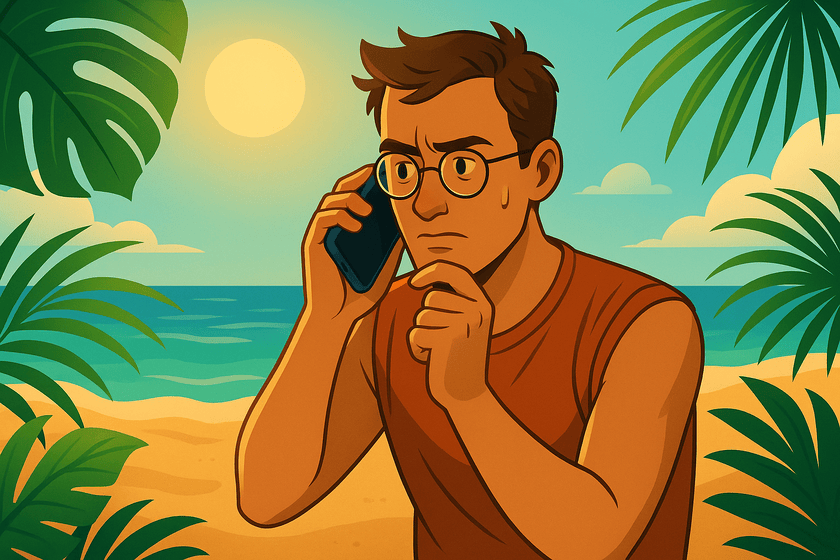

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [4]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [5]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

# Priorytet ewakuacji


In [6]:
display(pd.crosstab(
    titanic_df['Survived'],
    titanic_df['Sex'],
    normalize='columns'
    ) * 100)


Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


# Odpowiedzi na pytania

1. **Czy wszystkie kolumny są istotne w kontekście zadania?**

# Podział kolumn pod kątem przydatności w modelu

## Kolumny przydatne (Zostają w modelu)

* **`Sex`** — Kobiety miały priorytet podczas ewakuacji (przeżyło ponad 70% kobiet vs ok. 20% mężczyzn).
* **`Pclass`** - Klasa podróży (1, 2, 3) decydowała o bliskości do pokładu z łodziami i statusie społecznym.
* **`Age`** — Dzieci miały większą szansę na ratunek (wymaga uzupełnienia braków).
* **`Fare`** — Informuje o zamożności i dokładnym usytuowaniu na statku.
* **`SibSp` & `Parch`** — Informują o liczbie rodzeństwa/małżonków i rodziców/dzieci. Pozwalają stworzyć cechę wielkości rodziny (`FamilySize`).
* **`Embarked`** — Port zaokrętowania (C, Q, S). Może wskazywać na zamożność pasażerów w danym mieście.

---

## Kolumny nieprzydatne (Do usunięcia)

* **`PassengerId`** — Zwykły numer wiersza. Nie ma żadnego wpływu na przeżycie.
* **`Ticket`** — Unikalny kod biletu (często ciąg przypadkowych liter i cyfr). Brak bezpośredniej wartości predykcyjnej.

---

## Kolumny "ukryte" (Warto z nich coś wyciągnąć, a potem usunąć)

* **`Name`** — Sama nazwa jest nieprzydatna, ale zawiera **tytuł** (np. *Mr*, *Mrs*, *Master*, *Miss*).
* **`Cabin`** — Ma 77% braków. Zamiast usuwać od razu, zrób zmienną `HasCabin` (1 jeśli miał kabinę, 0 jeśli brak) lub wyciągnij literę pokładu (`Deck`), a surową `Cabin` usuń.




2. **Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz?**

Tak w kolumnach: `Cabin, Age, Fare, Embarked`

,missing,missing_percentage (%)
Cabin,687,77.10
Age,177,19.87
Fare,98,11.00
Embarked,2,0.22


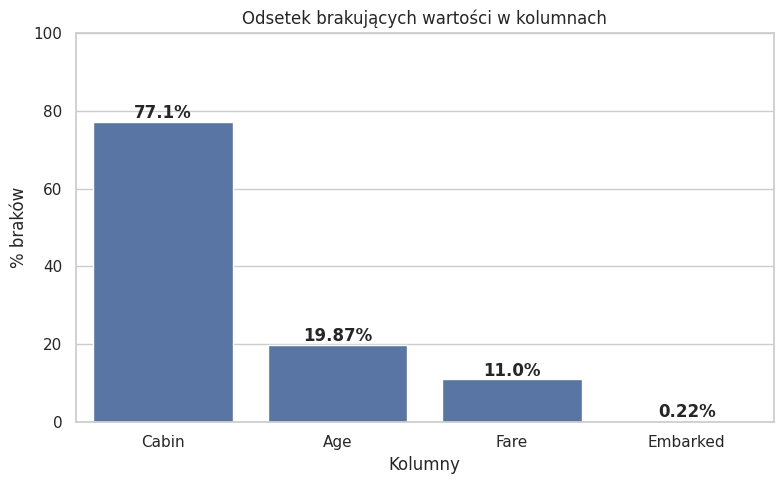

In [7]:
missing_matrix = pd.DataFrame({
    'missing': titanic_df.isna().sum(),
    'missing_percentage (%)': (titanic_df.isna().sum() / len(titanic_df) * 100).round(2)
})

missing_data_filtered = missing_matrix[missing_matrix['missing'] > 0].sort_values(by='missing', ascending=False)


# wyswietlamy tylko kolumny z brakami, posortowane malejaco
display(missing_matrix[missing_matrix['missing_percentage (%)'] > 0].sort_values(by='missing_percentage (%)', ascending=False))

# wykres1
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=missing_data_filtered.index,
    y=missing_data_filtered["missing_percentage (%)"],
    ax=ax,
    color="#4C72B0"
)

ax.set_ylabel("% braków")
ax.set_xlabel("Kolumny")
ax.set_title("Odsetek brakujących wartości w kolumnach")
ax.set_ylim(0, 100)
# Poprawione pętla: iteruje po odfiltrowanych danych
for i, v in enumerate(missing_data_filtered["missing_percentage (%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

3. **Czy typy danych są odpowiednie do znaczenia kolumny?**

Nie.

Pclass (Klasa podróży) -> Typ kategoryczny uporządkowany

Name --> str

Sex --> Label Encoding (0 lub 1)

Age --> int64

Ticket --> str

Embarked --> typ kategoryczne nieuporządkowane (category)

In [8]:
display(Markdown('### Informacje na temat kolumn'))
titanic_df.info()

display(Markdown('### Podstawowe statystyki'))
display(titanic_df.describe(include="all").T)

display(Markdown('### 5 pierwszych wierszy'))
display(titanic_df.head())

### Informacje na temat kolumn

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


### Podstawowe statystyki

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,793.0,NaN,NaN,NaN,33.123938,51.578312,0.0,7.925,14.5,31.275,512.3292
Cabin,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5 pierwszych wierszy

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Zmiana typów danych

In [9]:
# A. Pclass -> Typ kategoryczny uporządkowany
pclass_order = pd.CategoricalDtype(categories=[1, 2, 3], ordered=True)
titanic_df['Pclass'] = titanic_df['Pclass'].astype(pclass_order)

# B. Name & Ticket -> Typ tekstowy (str / string)
titanic_df['Name'] = titanic_df['Name'].astype('string')
titanic_df['Ticket'] = titanic_df['Ticket'].astype('string')

# C. Sex -> Mapowanie na wartości numeryczne (0 / 1)
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# D. Cabin oraz Embarked -> Typy kategoryczne nieuporządkowane
titanic_df['Cabin'] = titanic_df['Cabin'].astype('category')
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')

display(Markdown("### 3. Weryfikacja końcowa struktury danych"))
titanic_df.info()

### 3. Weryfikacja końcowa struktury danych

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Name      891 non-null    string  
 3   Sex       891 non-null    int64   
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    string  
 8   Fare      793 non-null    float64 
 9   Cabin     204 non-null    category
 10  Embarked  889 non-null    category
dtypes: category(3), float64(2), int64(4), string(2)
memory usage: 71.6 KB


## Ekstracja nowych cech



In [10]:
# wyciągnięcie tytulu z nazwiska (Mr, Mrs, Miss, Master itp.)
titanic_df['Title'] = titanic_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# tworzenie zmiennych dotyczacych rodziny (suma + pasazer)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

# IsAlone: Flaga 1/0 – sprawdzamy czy rozmiar rodziny wynosi 1
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

# tworzenie zmiennych z kolumny Cabin
titanic_df['Deck'] = titanic_df['Cabin'].str[0].astype('category')
titanic_df['HasCabin'] = (titanic_df['Cabin'].notna()).astype(int)

# weryfikacja
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    category
 2   Name        891 non-null    string  
 3   Sex         891 non-null    int64   
 4   Age         714 non-null    float64 
 5   SibSp       891 non-null    int64   
 6   Parch       891 non-null    int64   
 7   Ticket      891 non-null    string  
 8   Fare        793 non-null    float64 
 9   Cabin       204 non-null    category
 10  Embarked    889 non-null    category
 11  Title       891 non-null    string  
 12  FamilySize  891 non-null    int64   
 13  IsAlone     891 non-null    int64   
 14  Deck        204 non-null    category
 15  HasCabin    891 non-null    int64   
dtypes: category(4), float64(2), int64(7), string(3)
memory usage: 100.7 KB


## Uzupełnienie brakujących danych i usuniecie zbednych kolumn

In [11]:
# 1. Uzupełnienie Age medianą z grupy Title + zabezpieczenie globalną medianą
titanic_df['Age'] = titanic_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

# 2. Uzupełnienie Fare medianą z danej Pclass
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# 3. Uzupełnienie Embarked dominantą (mode)
most_frequent_embarked = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(most_frequent_embarked)

# 4. Obsługa braku Deck jako nowej kategorii 'Unknown'
if 'Unknown' not in titanic_df['Deck'].cat.categories:
    titanic_df['Deck'] = titanic_df['Deck'].cat.add_categories('Unknown')
titanic_df['Deck'] = titanic_df['Deck'].fillna('Unknown')

# usuuwanie
# Usunięcie surowych i zbędnych kolumn
cols_to_drop = ['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']

titanic_df = titanic_df.drop(columns=cols_to_drop, errors='ignore')

# Weryfikacja
titanic_df.info()

# Podgląd końcowy
titanic_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    category
 2   Sex         891 non-null    int64   
 3   Age         891 non-null    float64 
 4   Fare        891 non-null    float64 
 5   Embarked    891 non-null    category
 6   Title       891 non-null    string  
 7   FamilySize  891 non-null    int64   
 8   IsAlone     891 non-null    int64   
 9   Deck        891 non-null    category
 10  HasCabin    891 non-null    int64   
dtypes: category(3), float64(2), int64(5), string(1)
memory usage: 65.9 KB


/tmp/ipykernel_74775/962954236.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))


,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone,Deck,HasCabin
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,7.2500,S,Mr,2,0,Unknown,0
2,1,1,1,38.0,71.2833,C,Mrs,2,0,C,1
3,1,3,1,26.0,7.9250,S,Miss,1,1,Unknown,0
4,1,1,1,35.0,53.1000,S,Mrs,2,0,C,1
5,0,3,0,35.0,8.0500,S,Mr,1,1,Unknown,0


4. **Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne?**


koluny: ['Survived', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']


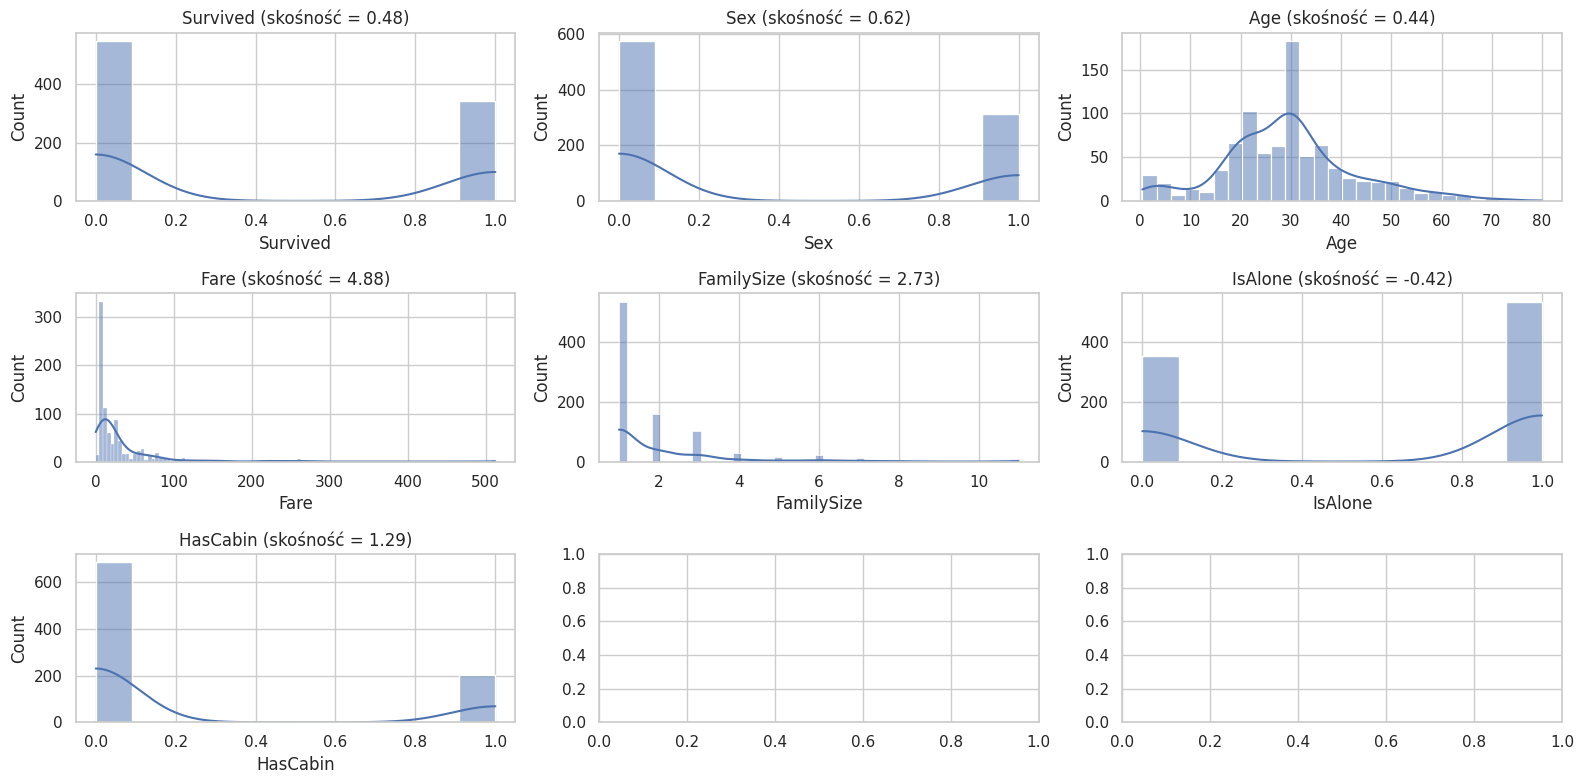

In [12]:
numeric_cols = titanic_df.select_dtypes(exclude=['category', 'string']).columns.tolist()
print(f'koluny: {numeric_cols}')

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(titanic_df[col], kde=True, ax=ax, color="#4C72B0")
    skew = titanic_df[col].skew()
    ax.set_title(f"{col} (skośność = {skew:.2f})")

# for ax in axes[-2:]:
#     ax.axis("off")

plt.tight_layout()
plt.show()


### Najbradziej użyteczne do predykcji są:

```
Fare, Age, FamilySize
```



5. **Która zmienna oznacza predykowaną klasę?**

Zgodnie z treścią zadania:

```
Survived
```





6. **Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych jak i numerycznych?**


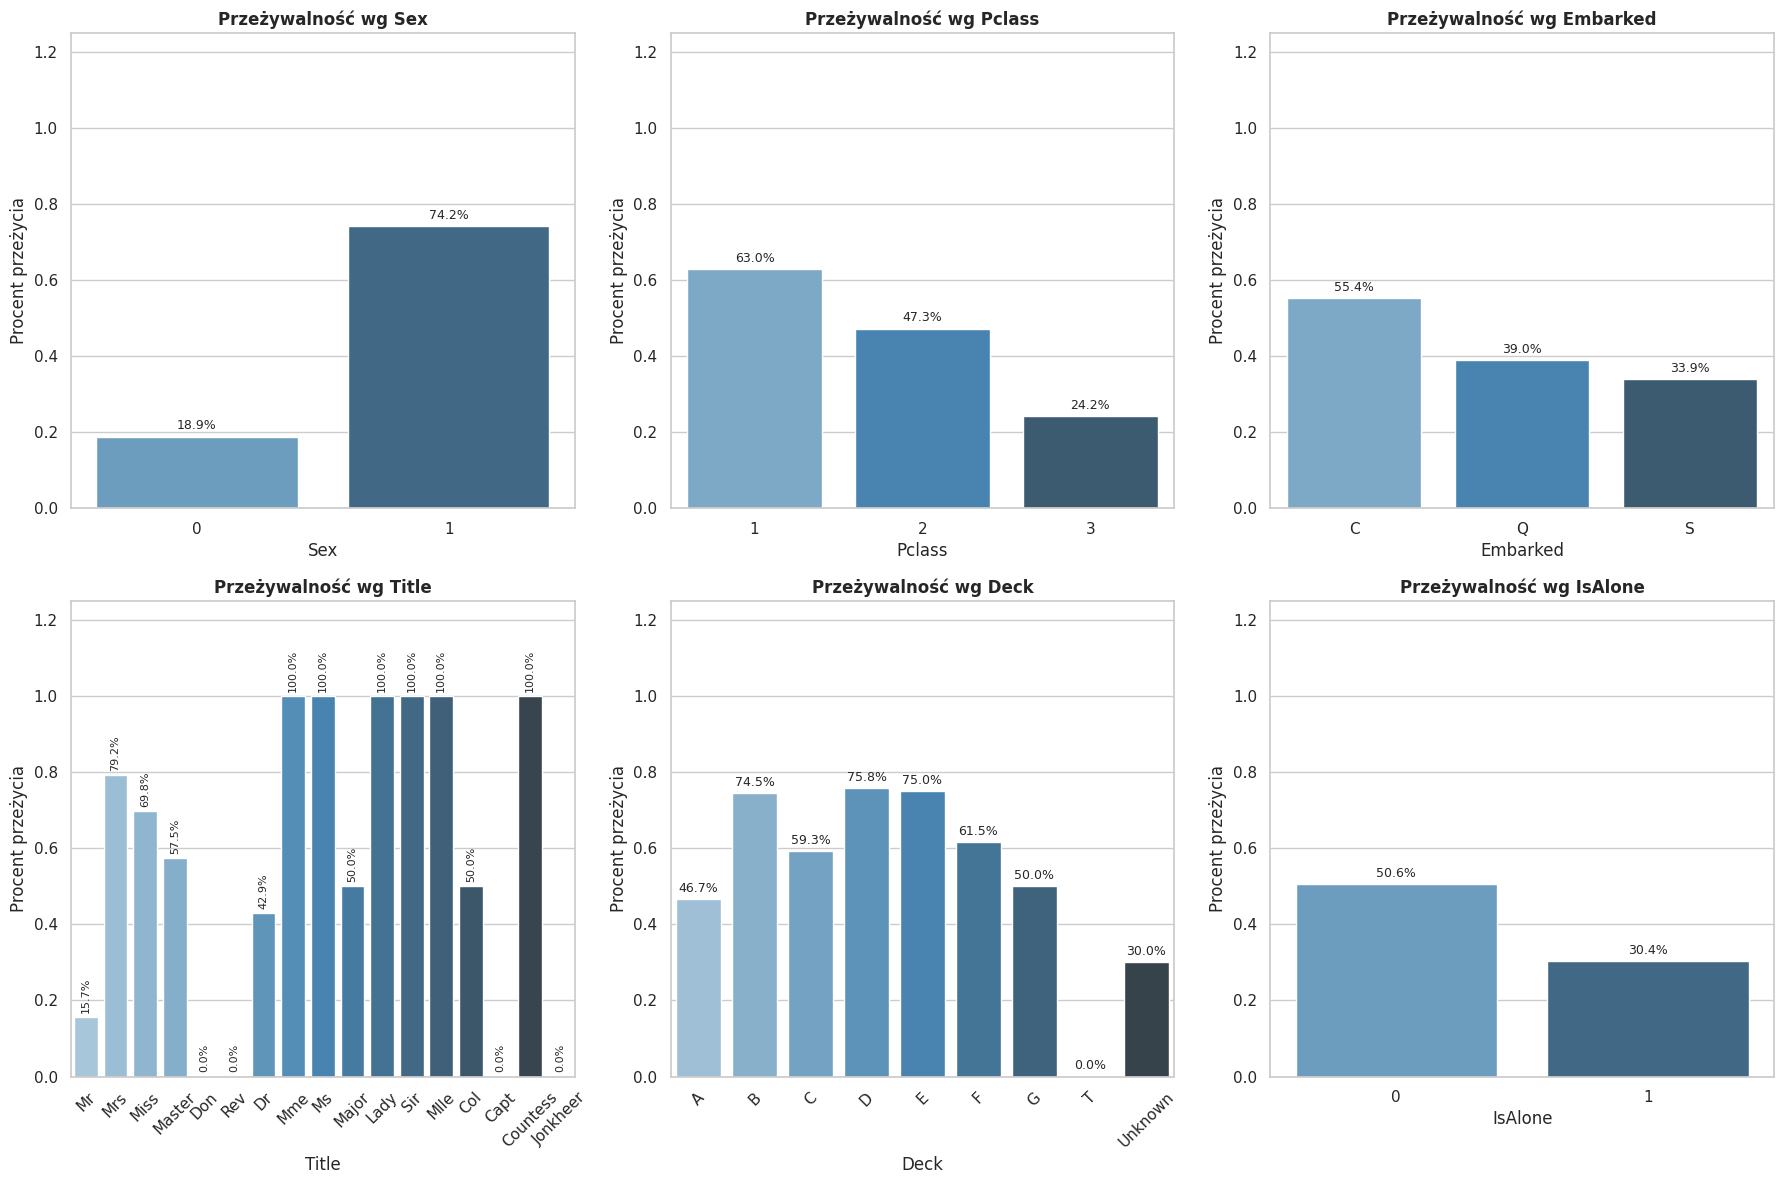

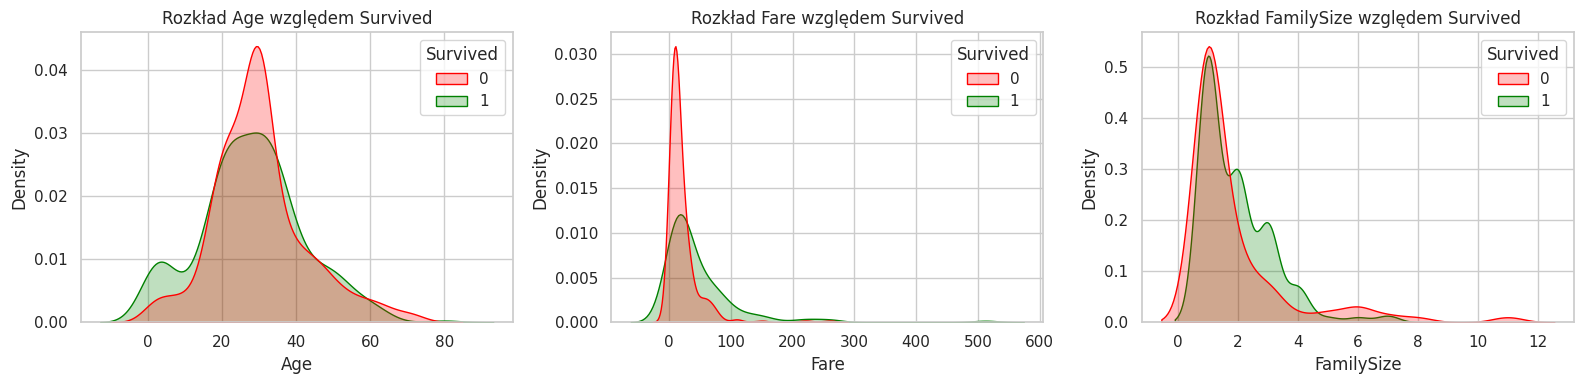

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck', 'IsAlone']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.barplot(
        data=titanic_df,
        x=col,
        y='Survived',
        ax=ax,
        hue=col,
        palette='Blues_d',
        legend=False,
        errorbar=None
    )
    ax.set_title(f'Przeżywalność wg {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Procent przeżycia')
    ax.set_xlabel(col)
    ax.set_ylim(0, 1.25)

    if col in ['Title', 'Deck']:
        ax.tick_params(axis='x', rotation=45)

    # nanoszenie etykiet
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height >= 0:
            # dla Title uzywamy obrotu etykiety o 90 stopni, aby uniknać nachodzenia
            rotation_val = 90 if col == 'Title' else 0
            font_sz = 8 if col == 'Title' else 9

            ax.annotate(
                f"{height*100:.1f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                xytext=(0, 3),
                textcoords='offset points',
                fontsize=font_sz,
                rotation=rotation_val
            )

plt.tight_layout()
plt.show()

# zmienne numeryczne vs Survived
num_cols = ['Age', 'Fare', 'FamilySize']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(
        data=titanic_df,
        x=col,
        hue='Survived',
        ax=ax,
        common_norm=False,
        fill=True,
        palette={0: 'red', 1: 'green'}
    )
    ax.set_title(f'Rozkład {col} względem Survived')

plt.tight_layout()
plt.show()

7. **Czy końcowe rozkłady zawierają wartości skrajne?**

Tak, końcowe rozkłady zawierają wartości skrajne, szczególnie w przypadku cech Fare, Age oraz FamilySize. Najbardziej ekstremalne outliery występują w cenie biletu (Fare), gdzie pojedyncze luksusowe rezerwacje przekraczają 500 USD przy medianie wynoszącej kilkanaście dolarów

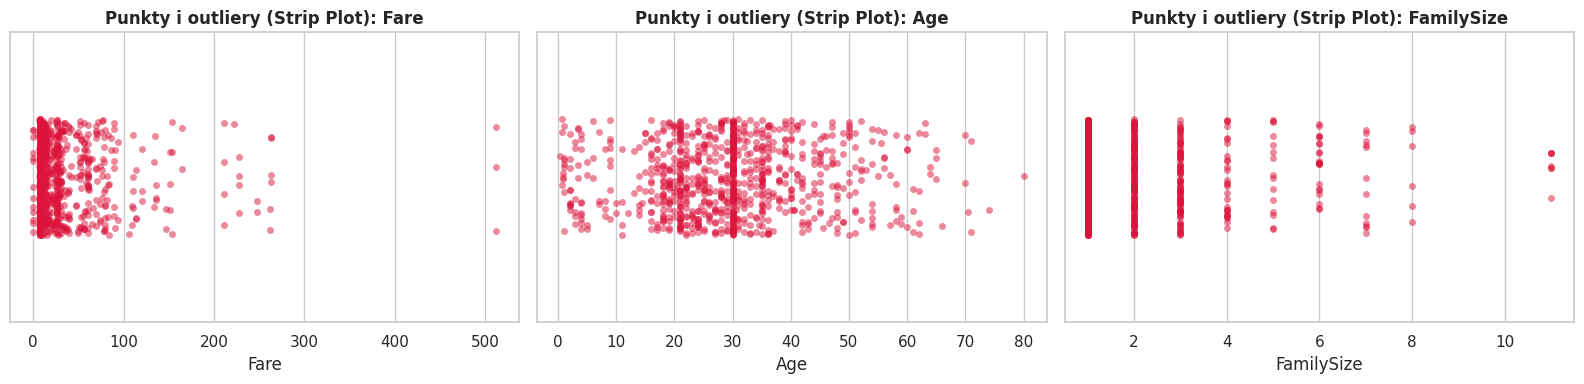

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['Fare', 'Age', 'FamilySize']):
    # stripplot z dodanym szumem (jitter), aby punkty nie nachodzily idealnie na siebie
    sns.stripplot(data=titanic_df, x=col, ax=ax, color='crimson', alpha=0.5, jitter=0.2)
    ax.set_title(f'Punkty i outliery (Strip Plot): {col}', fontweight='bold')

plt.tight_layout()
plt.show()

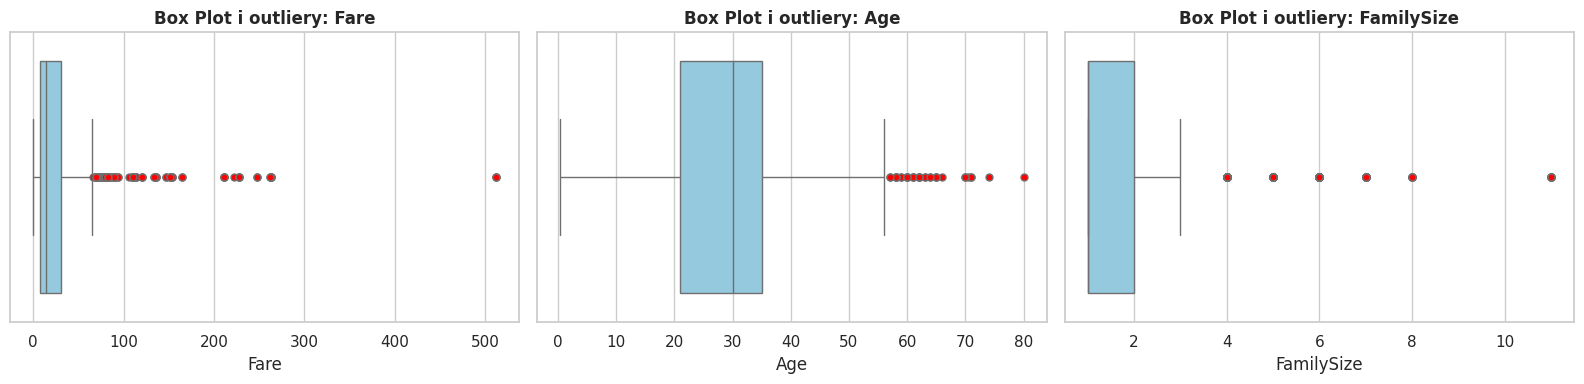

In [15]:
num_cols = ['Fare', 'Age', 'FamilySize']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        x=titanic_df[col],
        ax=ax,
        color='skyblue',
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
    )
    ax.set_title(f'Box Plot i outliery: {col}', fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

## Końcowe kodowanie

In [16]:
# Age -> Mapowanie na wartości int
titanic_df['Age'] = titanic_df['Age'].astype('int64')

# zakodowanie danych kategorycznych na hot one
titanic_df = pd.get_dummies(
    titanic_df,
    columns=['Embarked', 'Title', 'Deck'],
    drop_first=True,
    dtype=int
)

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    category
 2   Sex             891 non-null    int64   
 3   Age             891 non-null    int64   
 4   Fare            891 non-null    float64 
 5   FamilySize      891 non-null    int64   
 6   IsAlone         891 non-null    int64   
 7   HasCabin        891 non-null    int64   
 8   Embarked_Q      891 non-null    int64   
 9   Embarked_S      891 non-null    int64   
 10  Title_Col       891 non-null    int64   
 11  Title_Countess  891 non-null    int64   
 12  Title_Don       891 non-null    int64   
 13  Title_Dr        891 non-null    int64   
 14  Title_Jonkheer  891 non-null    int64   
 15  Title_Lady      891 non-null    int64   
 16  Title_Major     891 non-null    int64   
 17  Title_Master    891 n

## 8. Walidacja końcowa

In [17]:
# Tworzy podsumowanie ilościowe i procentowe
nan_summary = pd.DataFrame({
    'Liczba_NaN': titanic_df.isna().sum(),
    'Procent_NaN (%)': (titanic_df.isna().sum() / len(titanic_df) * 100).round(2)
})

# Wyświetla tylko kolumny z brakami, posortowane malejąco
display(nan_summary[nan_summary['Liczba_NaN'] > 0].sort_values(by='Liczba_NaN', ascending=False))

,Liczba_NaN,Procent_NaN (%)


In [18]:
assert titanic_df.isna().sum().sum() == 0, "W zbiorze wciąż są braki danych!"
print("Brak braków danych w finalnym zbiorze ✅")
print(f"Finalny kształt zbioru: {titanic_df.shape}")
titanic_df.describe().T


Brak braków danych w finalnym zbiorze ✅
Finalny kształt zbioru: (891, 34)


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.0,0.00,0.0,1.000,1.0000
Sex,891.0,0.352413,0.477990,0.0,0.00,0.0,1.000,1.0000
Age,891.0,29.371493,13.277422,0.0,21.00,30.0,35.000,80.0000
Fare,891.0,31.756069,49.325538,0.0,8.05,14.0,31.275,512.3292
FamilySize,891.0,1.904602,1.613459,1.0,1.00,1.0,2.000,11.0000
IsAlone,891.0,0.602694,0.489615,0.0,0.00,1.0,1.000,1.0000
HasCabin,891.0,0.228956,0.420397,0.0,0.00,0.0,0.000,1.0000
Embarked_Q,891.0,0.086420,0.281141,0.0,0.00,0.0,0.000,1.0000
Embarked_S,891.0,0.725028,0.446751,0.0,0.00,1.0,1.000,1.0000
Title_Col,891.0,0.002245,0.047351,0.0,0.00,0.0,0.000,1.0000
